<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Scan All Single-Point Variants for Thermal Stability and Solubility

Score all single-point variants of a target sequence and visualize the mutational landscape.

<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://www.svgrepo.com/show/354202/postman-icon.svg" style="height: 15px; float: left; padding-right: 10px;"><a href="https://api.biolm.ai/">  <h5 style="margin: 0;"><b>Postman API Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Python-logo-notext.svg/1869px-Python-logo-notext.svg.png" style="height: 15px; float: left; padding-right: 10px;"><a href="https://docs.biolm.ai/en/latest/index.html"><h5 style="margin: 0;"><b>Python SDK Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
    </tr>
</table>

<br>

---

**What you'll learn:**
- Generating a complete single-point mutant library programmatically
- Running multi-model predictions with parallel stages
- Visualizing a ΔTm mutational landscape heatmap
- Multi-model consensus ranking

**Requirements:**
```
pip install biolmai matplotlib numpy
export BIOLMAI_TOKEN=your-token-here
```

## Setup

In [1]:
import os
from biolmai.pipeline import (
    DataPipeline, DuckDBDataStore,
    ThresholdFilter, RankingFilter,
    ValidAminoAcidFilter, EmbeddingSpec,
    DiversitySamplingFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    raise EnvironmentError(
        "Set BIOLMAI_TOKEN before running.\n"
        "Get one at https://biolm.ai/ui/accounts/user-api-tokens/"
    )
import numpy as np
import matplotlib.pyplot as plt

## Generate the single-point mutant library

In [2]:
WILD_TYPE = "MKTAYIAKQRQISFVKSHFSRQLEER"
CDR3_START, CDR3_END = 5, 22   # 17-residue target region
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

variants = [WILD_TYPE]  # include wild type as reference
for pos in range(CDR3_START, CDR3_END):
    for aa in AMINO_ACIDS:
        if aa != WILD_TYPE[pos]:
            mutant = WILD_TYPE[:pos] + aa + WILD_TYPE[pos+1:]
            variants.append(mutant)

print(f"{len(variants)} sequences ({len(variants)-1} single-point variants + wild type)")

324 sequences (323 single-point variants + wild type)


## Score with multiple models

Both prediction stages run in parallel. 324 sequences × 2 models, all cached in DuckDB.

In [3]:
from biolmai.pipeline import DataPipeline, ValidAminoAcidFilter, ThresholdFilter, RankingFilter

pipeline = DataPipeline(sequences=variants, verbose=True)

pipeline.add_filter(ValidAminoAcidFilter(), stage_name="validate")

pipeline.add_prediction(
    "temberture-regression", extractions="prediction",
    columns="melting_temperature", stage_name="tm",
    depends_on=["validate"],
)
pipeline.add_prediction(
    "biolmsol", extractions="solubility_score",
    columns="solubility", stage_name="sol",
    depends_on=["validate"],
)

# Keep variants that beat wild-type Tm floor, then top 20 by solubility
pipeline.add_filter(ThresholdFilter("melting_temperature", min_value=48.0))
pipeline.add_filter(RankingFilter("solubility", n=20, ascending=False))

pipeline.run()
pipeline.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('tm', depends_on=['validate'])
Added stage: PredictionStage('sol', depends_on=['validate'])
Added stage: FilterStage('filter_3', depends_on=['sol'])
Added stage: FilterStage('filter_4', depends_on=['filter_3'])

############################################################
# Pipeline: DataPipeline
# Run ID: 20260617_103630_fa7fa64e
# Initial sequences: 324
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: tm, sol (parallel)
  Level 3: filter_3
  Level 4: filter_4

Stage: validate
Input: 324 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/324
  Remaining: 324



StageResult(validate: in=324, out=324, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: tm
Input: 324 sequences
Depends on: validate
  Cached: 0/324
  To compute: 324
  Calling temberture-regression.predict...


  temberture-regression:   0%|          | 0/11 [00:00<?, ?batch/s]


Stage: sol
Input: 324 sequences
Depends on: validate


  Cached: 0/324
  To compute: 324
  Calling biolmsol.predict...


  biolmsol:   0%|          | 0/11 [00:00<?, ?batch/s]

  Completed: 324 sequences in 11 batches (max 5 concurrent)

StageResult(sol: in=324, out=324, cached=0, computed=324, filtered=0, time=186.9s)


  Completed: 324 sequences in 11 batches (max 5 concurrent)

StageResult(tm: in=324, out=324, cached=0, computed=324, filtered=0, time=200.3s)

Stage: filter_3
Input: 324 sequences
Depends on: sol
  Applying filter: ThresholdFilter(column='melting_temperature', min=48.0)
  Filtered out: 78/324
  Remaining: 246

StageResult(filter_3: in=324, out=246, cached=0, computed=0, filtered=78, time=0.0s)

Stage: filter_4
Input: 246 sequences
Depends on: filter_3
  Applying filter: RankingFilter(column='solubility', n=20, method='top')
  Filtered out: 226/246
  Remaining: 20

StageResult(filter_4: in=246, out=20, cached=0, computed=0, filtered=226, time=0.0s)

############################################################
# Pipeline completed in 200.5s
# Final sequences: 20
############################################################



,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,324,324,0,0,0,0.0
1,tm,324,324,0,0,324,200.3
2,sol,324,324,0,0,324,186.9
3,filter_3,324,246,78,0,0,0.0
4,filter_4,246,20,226,0,0,0.0


## Compute ΔTm relative to wild type

In [4]:
df = pipeline.query("""
    SELECT s.sequence,
           MAX(CASE WHEN p.prediction_type = 'melting_temperature' THEN p.value END) AS tm,
           MAX(CASE WHEN p.prediction_type = 'solubility' THEN p.value END) AS solubility
    FROM sequences s
    JOIN predictions p ON s.sequence_id = p.sequence_id
    GROUP BY s.sequence
""")

wt_rows = df[df["sequence"] == WILD_TYPE]["tm"]
if len(wt_rows) == 0:
    raise RuntimeError(
        "Wild-type sequence has no Tm prediction — check API connectivity and BIOLMAI_TOKEN."
    )
wt_tm = wt_rows.iloc[0]
df["delta_tm"] = df["tm"] - wt_tm
print(f"Wild-type Tm: {wt_tm:.1f}°C")
df.sort_values("delta_tm", ascending=False).head(10)

Wild-type Tm: 51.1°C


,sequence,tm,solubility,delta_tm
183,MKTAYIAKQRQISFVKSHFSRWLEER,61.396854,0.657912,10.273907
191,MKTAYIAKQRQESFVKSHFSRQLEER,57.286594,0.943208,6.163647
217,MKTAYIAKQRQISFVKSEFSRQLEER,57.137478,0.862783,6.014530
256,MKTAYIAKQRQISFVKSAFSRQLEER,56.999977,0.860618,5.877029
301,MKTAYIAKQRQISFVKSHRSRQLEER,54.931290,1.243444,3.808342
2,MKTAYRAKQRQISFVKSHFSRQLEER,54.901398,1.193492,3.778450
121,MKTAYKAKQRQISFVKSHFSRQLEER,54.590424,1.213113,3.467476
97,MKTAYIAKQRQISFVKSHLSRQLEER,54.496346,0.878563,3.373398
186,MKTAYEAKQRQISFVKSHFSRQLEER,54.472130,0.957137,3.349182
117,MKTAYIAKQRQISFVKSHFARQLEER,54.308273,0.873038,3.185326


## Mutational landscape heatmap

Each cell shows the predicted ΔTm for substituting the column's wild-type residue with the row's amino acid. Red = stabilizing, blue = destabilizing.

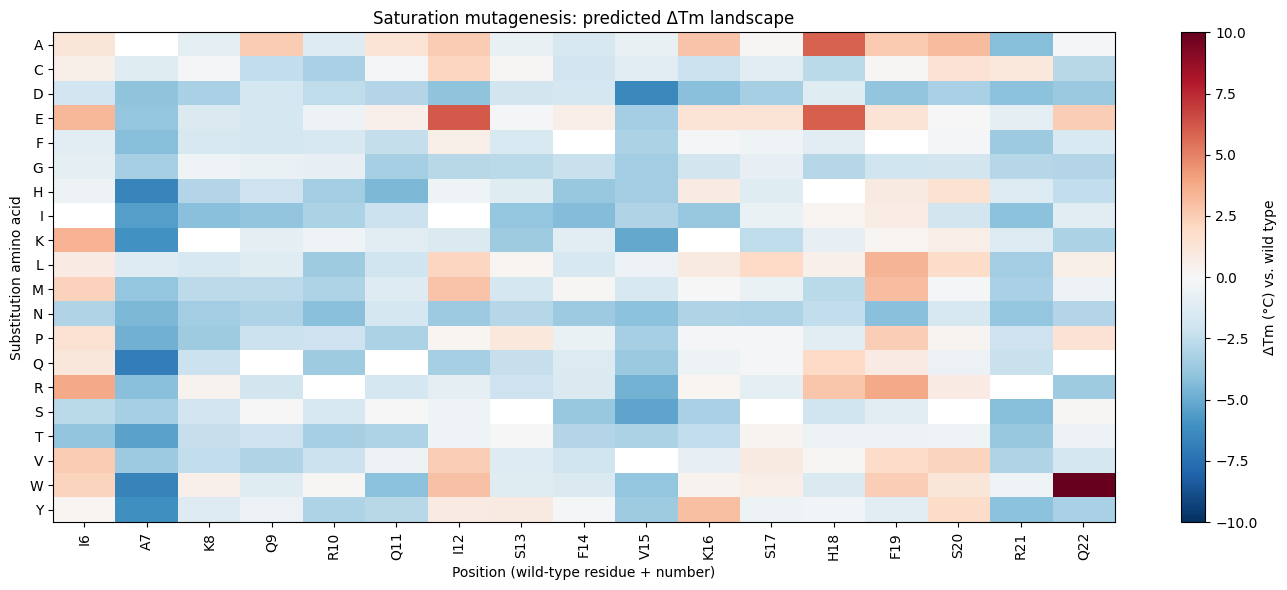

In [5]:
positions = list(range(CDR3_START, CDR3_END))
aa_list = sorted(AMINO_ACIDS)
heatmap = np.full((len(aa_list), len(positions)), np.nan)

for i, aa in enumerate(aa_list):
    for j, pos in enumerate(positions):
        if aa == WILD_TYPE[pos]:
            continue
        mutant = WILD_TYPE[:pos] + aa + WILD_TYPE[pos+1:]
        row = df[df["sequence"] == mutant]
        if len(row) > 0:
            heatmap[i, j] = row["delta_tm"].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap, cmap="RdBu_r", aspect="auto", vmin=-10, vmax=10)
ax.set_xticks(range(len(positions)))
ax.set_xticklabels([WILD_TYPE[p] + str(p+1) for p in positions], rotation=90)
ax.set_yticks(range(len(aa_list)))
ax.set_yticklabels(aa_list)
plt.colorbar(im, ax=ax, label="ΔTm (°C) vs. wild type")
ax.set_title("Saturation mutagenesis: predicted ΔTm landscape")
ax.set_xlabel("Position (wild-type residue + number)")
ax.set_ylabel("Substitution amino acid")
plt.tight_layout()
plt.show()

## Multi-model consensus

Normalize scores across models and rank by average — mutations that score well on independent predictors are more likely to validate.

In [6]:
import pandas as pd

df_filt = pipeline.get_final_data()
df_filt["tm_norm"] = (df_filt["melting_temperature"] - df_filt["melting_temperature"].mean()) / df_filt["melting_temperature"].std()
df_filt["sol_norm"] = (df_filt["solubility"] - df_filt["solubility"].mean()) / df_filt["solubility"].std()
df_filt["consensus"] = (df_filt["tm_norm"] + df_filt["sol_norm"]) / 2

print("Top 10 consensus candidates:")
df_filt.nlargest(10, "consensus")[["sequence", "melting_temperature", "solubility", "consensus"]]

Top 10 consensus candidates:


,sequence,melting_temperature,solubility,consensus
17,MKTAYIAKQRQISFVKSHRSRQLEER,54.931290,1.243444,1.486047
14,MKTAYKAKQRQISFVKSHFSRQLEER,54.590424,1.213113,1.177959
10,MKTAYRAKQRQISFVKSHFSRQLEER,54.901398,1.193492,1.110784
19,MKTAYIAKQRQISFVKSHKSRQLEER,51.282913,1.262610,0.720199
4,MKTAYIAKQRQISKVKSHFSRQLEER,50.021278,1.278279,0.521941
7,MKTAYIAKQRQISFVKSRFSRQLEER,53.886021,1.136280,0.437070
13,MKTAYIAKQRQISRVKSHFSRQLEER,49.715118,1.259116,0.304719
0,MKTAYIAKQRQISFVKSHFKRQLEER,51.815460,1.173266,0.194686
6,MKTAYIAKQRQKSFVKSHFSRQLEER,49.672829,1.229878,0.078906
18,MKTAYIAKQRQISFVKSHFRRQLEER,51.908463,1.154100,0.076674


## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.